# Chow Test - Known Breakpoint

In [8]:
import numpy as np
import pandas as pd
from scipy import stats

In [9]:
np.random.seed(42)
n = 140
break_point = 70

In [10]:
series = np.array([
    50 + np.random.normal(loc=0, scale=3, size=break_point),
    80 + np.random.normal(loc=0, scale=3, size=n-break_point)
]).flatten()

In [12]:
len(series)

140

In [13]:
t = np.arange(n)
t

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139])

In [14]:
before = series[:break_point]
after = series[break_point:]

In [17]:
# Fit a mean model to each segment separately
mean_before = before.mean()
mean_after = after.mean()

In [18]:
print(mean_before, mean_after)

49.59586353289545 79.8999646971052


In [19]:
# Run a t-test -  is the mean significantly different between segments?
t_stat, p_value = stats.ttest_ind(before, after)

In [20]:
print(f"Mean before break: {mean_before}")
print(f"Mean after break: {mean_after}")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Mean before break: 49.59586353289545
Mean after break: 79.8999646971052
T-statistic: -63.22505786508937
P-value: 8.920043486992541e-104


In [22]:
if p_value < 0.05:
    print("\nConclusion: Means are significantly different — structural break confirmed")
else:
    print("\nConclusion: No significant difference — no break detected at this point")


Conclusion: Means are significantly different — structural break confirmed


# Zivot-Andrews Test

In [24]:
# trim=0.15 tells the test to ignore the first and last 15% of the series when scanning — this prevents it from flagging edge effects as breaks. The output tells you both whether a break exists and where it most likely occurred.

In [25]:
from statsmodels.tsa.stattools import zivot_andrews

result = zivot_andrews(series, trim=0.15)

print(f"ZA Statistic  : {result[0]}")
print(f"p-value       : {result[1]}")
print(f"Break at t    : {result[4]}")          # estimated breakpoint location
print(f"Critical values: {result[2]}")

if result[1] < 0.05:
    print(f"\nStructural break detected at index {result[4]}")
else:
    print("\nNo structural break detected")

ZA Statistic  : -14.27148714434571
p-value       : 1e-05
Break at t    : 69
Critical values: {'1%': np.float64(-5.27644), '5%': np.float64(-4.81067), '10%': np.float64(-4.56618)}

Structural break detected at index 69


# CUSUM (Cumulative Sum)

In [26]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

In [28]:
np.random.seed(42)
n = 120
break_point = 60

In [29]:
series = np.concatenate([
    50 + np.random.normal(0, 3, break_point),
    80 + np.random.normal(0, 3, n - break_point)])

In [30]:
t = sm.add_constant(np.arange(n))
model = OLS(series, t).fit()
residuals = model.resid

In [32]:
# Cumulative sum of residuals
cusum = np.cumsum(residuals)
cusum_std = np.std(residuals)

In [33]:
# Confidence bands — if CUSUM exits these, structural break likely
upper = [cusum_std * 0.948 * np.sqrt(n) * (i / n + 0.5/n**(0.5)) for i in range(n)]
lower = [-u for u in upper]

In [34]:
upper

[np.float64(3.8231879619520712),
 np.float64(4.521203391399855),
 np.float64(5.219218820847638),
 np.float64(5.917234250295423),
 np.float64(6.615249679743207),
 np.float64(7.313265109190991),
 np.float64(8.011280538638776),
 np.float64(8.70929596808656),
 np.float64(9.407311397534343),
 np.float64(10.105326826982127),
 np.float64(10.80334225642991),
 np.float64(11.501357685877696),
 np.float64(12.19937311532548),
 np.float64(12.897388544773264),
 np.float64(13.595403974221048),
 np.float64(14.293419403668832),
 np.float64(14.991434833116616),
 np.float64(15.6894502625644),
 np.float64(16.387465692012185),
 np.float64(17.085481121459967),
 np.float64(17.783496550907753),
 np.float64(18.481511980355535),
 np.float64(19.17952740980332),
 np.float64(19.877542839251106),
 np.float64(20.575558268698888),
 np.float64(21.27357369814667),
 np.float64(21.971589127594456),
 np.float64(22.669604557042245),
 np.float64(23.367619986490027),
 np.float64(24.065635415937805),
 np.float64(24.7636508453

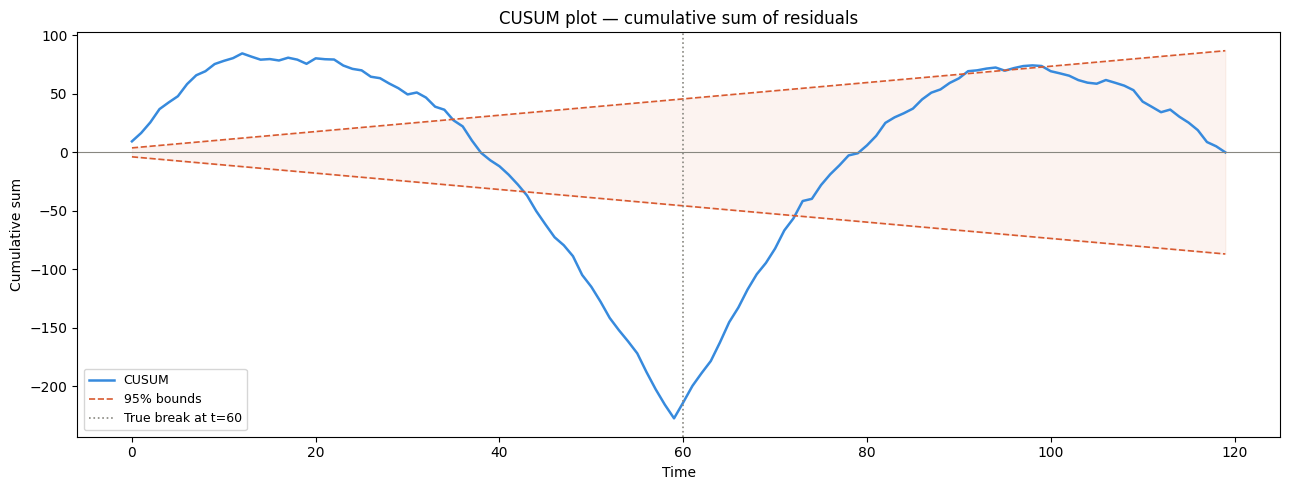

In [35]:
plt.figure(figsize=(13, 5))
plt.plot(cusum, color='#378ADD', linewidth=1.8, label='CUSUM')
plt.plot(upper, color='#D85A30', linestyle='--', linewidth=1.2, label='95% bounds')
plt.plot(lower, color='#D85A30', linestyle='--', linewidth=1.2)
plt.axvline(x=break_point, color='#888780', linestyle=':', linewidth=1.2, label=f'True break at t={break_point}')
plt.axhline(0, color='#888780', linewidth=0.8)
plt.fill_between(range(n), lower, upper, alpha=0.07, color='#D85A30')
plt.title('CUSUM plot — cumulative sum of residuals', fontsize=12)
plt.xlabel('Time')
plt.ylabel('Cumulative sum')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cusum.png', dpi=150, bbox_inches='tight')
plt.show()